# 📊 Employee Performance Analysis – Notebook Code
## Step 1 — Import Libraries & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load dataset
df = pd.read_csv("employee_performance.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

First 5 rows:
  Employee_ID   Department  Age  Salary  Projects_Completed  Working_Hours  \
0     E100000   Operations   49  106958                   0             45   
1     E100001        Sales   28   57926                  18             49   
2     E100002    Marketing   56  133215                  21             53   
3     E100003   Operations   49  128707                   7             37   
4     E100004  Engineering   35   43180                   2             57   

   Performance_Score Promotion_Status  
0                 38               No  
1                 77              Yes  
2                 91              Yes  
3                 42               No  
4                 40               No  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Employee_ID         4000 non-null   object
 1   Departm

## Step 2 — Mean, Median, Mode

In [2]:
mean_salary = df["Salary"].mean()
median_salary = df["Salary"].median()
mode_salary = df["Salary"].mode()[0]

print("Mean Salary:", mean_salary)
print("Median Salary:", median_salary)
print("Mode Salary:", mode_salary)

Mean Salary: 90095.38575
Median Salary: 90290.0
Mode Salary: 74135


## Step 3 — Variance & Standard Deviation

In [3]:
variance_projects = df["Projects_Completed"].var()
std_projects = df["Projects_Completed"].std()

print("Variance of Projects Completed:", variance_projects)
print("Standard Deviation of Projects Completed:", std_projects)

Variance of Projects Completed: 51.147139222305576
Standard Deviation of Projects Completed: 7.151722814980008


## Step 4 — Probability of Promotion

In [4]:
total_employees = len(df)
promoted = len(df[df["Promotion_Status"] == "Yes"])

prob_promotion = promoted / total_employees

print("Probability of Promotion:", prob_promotion)

Probability of Promotion: 0.248


## Step 5 — Contingency Table

In [5]:
contingency_table = pd.crosstab(df["Department"], df["Promotion_Status"])

print("Contingency Table:\n")
print(contingency_table)

Contingency Table:

Promotion_Status   No  Yes
Department                
Engineering       355  114
Finance           381  123
HR                402  111
IT                378  127
Marketing         392  131
Operations        366  122
Sales             378  139
Support           356  125


## Step 6 — Conditional Probability

In [7]:
high_perf = df[df["Performance_Score"] > 80]

cond_prob = len(high_perf[high_perf["Promotion_Status"] == "Yes"]) / len(high_perf)

print("P(Promotion | Performance_Score > 80):", cond_prob)

P(Promotion | Performance_Score > 80): 0.9647058823529412


## Step 7 — Histogram + Gaussian Curve

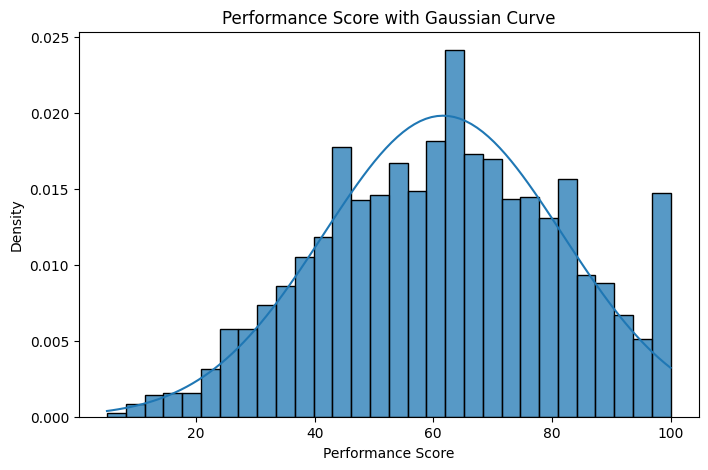

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["Performance_Score"], bins=30, stat="density")

mean = df["Performance_Score"].mean()
std = df["Performance_Score"].std()

x = np.linspace(df["Performance_Score"].min(),
                df["Performance_Score"].max(),100)

p = stats.norm.pdf(x, mean, std)

plt.plot(x, p)

plt.title("Performance Score with Gaussian Curve")
plt.xlabel("Performance Score")
plt.ylabel("Density")

plt.show()

## Step 8 — Skewness & Kurtosis

In [9]:
skew_salary = df["Salary"].skew()
kurt_salary = df["Salary"].kurt()

print("Skewness of Salary:", skew_salary)
print("Kurtosis of Salary:", kurt_salary)

Skewness of Salary: -0.016949998149457492
Kurtosis of Salary: -1.2253261222536909


## Step 9 — Q-Q Plot

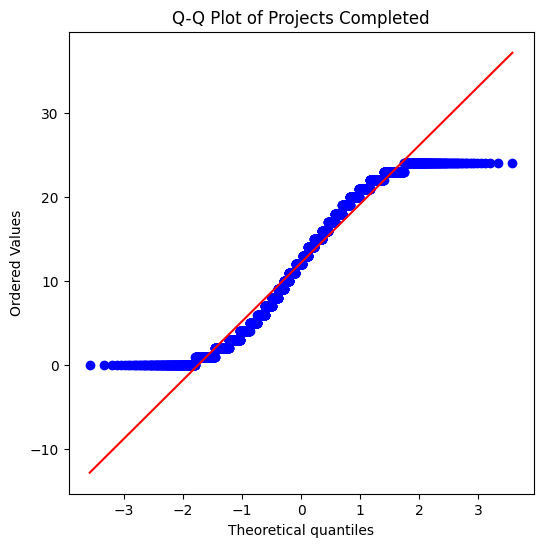

In [10]:
plt.figure(figsize=(6,6))

stats.probplot(df["Projects_Completed"], dist="norm", plot=plt)

plt.title("Q-Q Plot of Projects Completed")

plt.show()

## Step 10 — Vector Representation

In [11]:
vectors = df[["Projects_Completed","Working_Hours"]].head(5).values

print("Employee Work Vectors:\n", vectors)

v1 = vectors[0]
v2 = vectors[1]

Employee Work Vectors:
 [[ 0 45]
 [18 49]
 [21 53]
 [ 7 37]
 [ 2 57]]


## Step 11 — Dot Product

In [12]:
dot_product = np.dot(v1, v2)

print("Dot Product:", dot_product)

Dot Product: 2205


## Step 12 — Norms

In [13]:
# Norm 1
norm1 = np.linalg.norm(v1, ord=1)
print("Norm 1:", norm1)

# Norm 2
norm2 = np.linalg.norm(v1)
print("Norm 2:", norm2)

Norm 1: 45.0
Norm 2: 45.0


## Step 13 — Angle Between Vectors

In [14]:
cos_theta = dot_product / (np.linalg.norm(v1) * np.linalg.norm(v2))

angle = np.arccos(cos_theta)

angle_degrees = np.degrees(angle)

print("Angle between vectors:", angle_degrees)

Angle between vectors: 20.1706534118504
